<a href="https://colab.research.google.com/github/Shahadat-Karim/CNN-Development-Assignment/blob/main/CNN_21_45563_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Development on Fashion-MNIST Dataset
**Assignment: Mid-Term CNN Classification**

**Dataset:** Fashion-MNIST (Zalando Research) — 10 clothing categories, 70,000 grayscale 28×28 images

**Notebook Structure:**
1. Import Libraries
2. Load and Explore Dataset
3. Data Preprocessing & Augmentation
4. Define CNN Architecture
5. Training Loop with Validation
6. Evaluate Model on Test Set
7. Visualizations (Loss/Accuracy Curves, Confusion Matrix)
8. Analysis & Discussion of Results
9. Conclusions & Future Work

In [36]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" No GPU found. Go to Runtime → Change runtime type → GPU (T4) for faster training.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU Device: Tesla T4
GPU Memory: 15.6 GB


## 1. Import Libraries

In [37]:
#Standard Libraries
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

#PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Subset

#Torchvision
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

#Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

BATCH_SIZE  = 128
NUM_EPOCHS  = 30
LR          = 1e-3
DROPOUT     = 0.4
NUM_CLASSES = 10
NUM_WORKERS = 2

print(f"\nHyperparameters:")
print(f"  Batch Size : {BATCH_SIZE}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  LR         : {LR}")
print(f"  Dropout    : {DROPOUT}")
print(f"  Classes    : {NUM_CLASSES}")

Using device: cuda

Hyperparameters:
  Batch Size : 128
  Epochs     : 30
  LR         : 0.001
  Dropout    : 0.4
  Classes    : 10


## 2. Load and Explore Dataset

**Fashion-MNIST** is a drop-in replacement for MNIST consisting of 60,000 training and 10,000 test images of fashion articles from Zalando. Each image is 28×28 grayscale pixels belonging to one of 10 classes.

In [38]:
#Class Labels
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Download raw dataset (no augmentation) for exploration

raw_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download splits
raw_train = FashionMNIST(root='./data', train=True,  download=True, transform=raw_transform)
raw_test  = FashionMNIST(root='./data', train=False, download=True, transform=raw_transform)

print(f"Training samples : {len(raw_train)}")
print(f"Test samples     : {len(raw_test)}")
print(f"Image shape      : {raw_train[0][0].shape}   (C × H × W)")
print(f"Classes          : {CLASS_NAMES}")

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])   (C × H × W)
Classes          : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


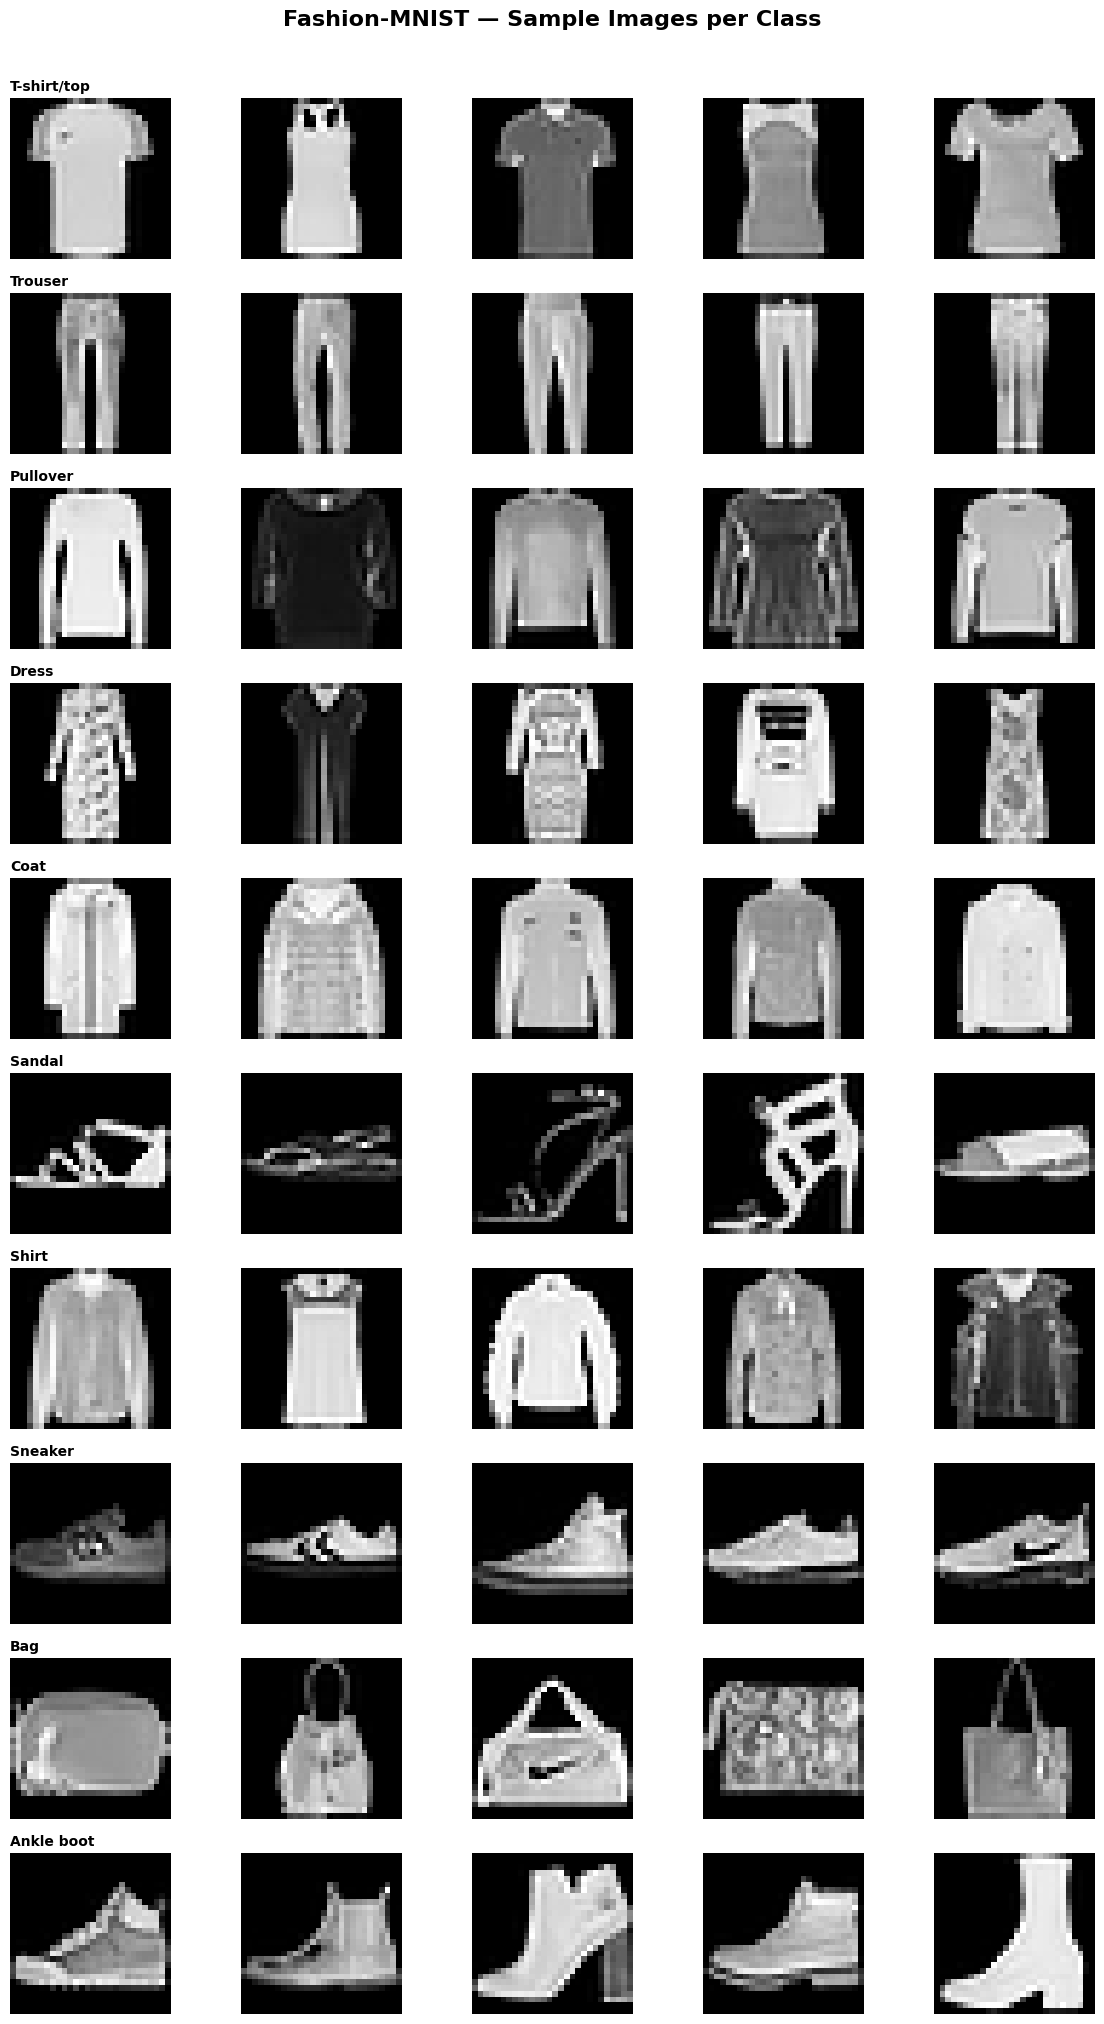

/tmp/ipykernel_4669/60216851.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')


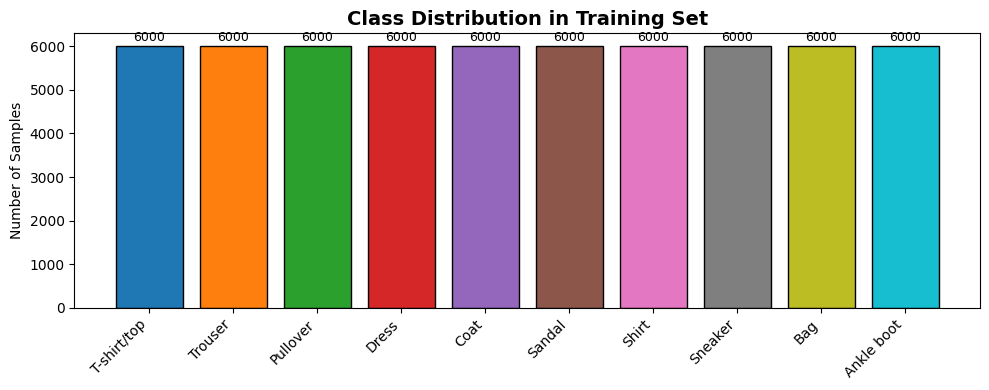

Dataset is perfectly balanced — 6,000 samples per class.


In [39]:
# Visualize sample images
fig, axes = plt.subplots(10, 5, figsize=(12, 20))
fig.suptitle('Fashion-MNIST — Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)

# Build index lists per class
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(raw_train):
    class_indices[label].append(idx)

for cls in range(NUM_CLASSES):
    sampled = random.sample(class_indices[cls], 5)
    for col, idx in enumerate(sampled):
        img, _ = raw_train[idx]
        # Un-normalize for display
        img_display = img.squeeze().numpy() * 0.3530 + 0.2860
        axes[cls, col].imshow(img_display, cmap='gray')
        axes[cls, col].axis('off')
        if col == 0:
            axes[cls, col].set_title(CLASS_NAMES[cls], fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

# Class distribution
labels = [raw_train[i][1] for i in range(len(raw_train))]
counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black')
ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count),
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print("Dataset is perfectly balanced — 6,000 samples per class.")

## 3. Data Preprocessing & Augmentation

- **Training**: Random horizontal flip + random crop (padding=4) to improve generalization
- **Validation/Test**: Only normalization (no augmentation — we evaluate on clean images)
- **Normalization**: Mean=0.2860, Std=0.3530 (computed from Fashion-MNIST training set)

In [40]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

# Create Datasets
# Training set: 60,000 samples with augmentation
train_dataset = FashionMNIST(root='./data', train=True,  download=False, transform=train_transform)

# Test set: 10,000 samples, no augmentation
test_dataset  = FashionMNIST(root='./data', train=False, download=False, transform=val_test_transform)

val_size   = 10_000
train_size = len(train_dataset) - val_size
train_indices = list(range(train_size))
val_indices   = list(range(train_size, len(train_dataset)))

train_subset = Subset(train_dataset, train_indices)

# Val subset uses val_test_transform (no augmentation)
val_dataset_clean = FashionMNIST(root='./data', train=True, download=False, transform=val_test_transform)
val_subset = Subset(val_dataset_clean, val_indices)

# DataLoaders
# pin_memory=True speeds up CPU→GPU transfer on Colab
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)} × {BATCH_SIZE} = {len(train_loader)*BATCH_SIZE} samples")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

#Sanity check: verify a batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape   : {images.shape}   (Batch × C × H × W)")
print(f"Labels shape  : {labels.shape}")
print(f"Pixel range   : [{images.min():.3f}, {images.max():.3f}]")

Train batches : 390 × 128 = 49920 samples
Val batches   : 79
Test batches  : 79

Batch shape   : torch.Size([128, 1, 28, 28])   (Batch × C × H × W)
Labels shape  : torch.Size([128])
Pixel range   : [-0.810, 2.023]


## 4.CNN Architecture

### Architecture Justification
| Component | Choice | Reason |
|---|---|---|
| Conv blocks | 3 blocks (32→64→128 filters) | Progressively deeper feature extraction |
| Kernel size | 3×3 | Standard; captures local patterns efficiently |
| Batch Norm | After every conv | Stabilizes training, allows higher LR |
| Activation | ReLU | Fast, avoids vanishing gradient |
| MaxPool 2×2 | After each block | Reduces spatial dims, adds translation invariance |
| Dropout | 0.4 after FC1 | Prevents co-adaptation / overfitting |
| FC layers | 128×7×7 → 512 → 10 | Gradual dimension reduction |
| Global Avg Pool | Before FC | Reduces parameters vs. flattening |


In [41]:
class FashionCNN(nn.Module):
    """
    Custom CNN for Fashion-MNIST classification.

    Architecture:
      Input: (B, 1, 28, 28)
      Block1: Conv(1→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool → (B, 32, 14, 14)
      Block2: Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool → (B, 64, 7, 7)
      Block3: Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → MaxPool → (B, 128, 3, 3)
              (Note: 7//2=3 due to integer division)
      AdaptiveAvgPool → (B, 128, 1, 1)
      Flatten → (B, 128)
      FC1: 128 → 256 → ReLU → Dropout(0.4)
      FC2: 256 → 10
    """

    def __init__(self, num_classes=10, dropout=0.4, use_bn=True):
        super(FashionCNN, self).__init__()
        self.use_bn = use_bn

        #Block 1: 1 → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(32) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(32) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.1)
        )

        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(64) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(64) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),       # 14×14 → 7×7
            nn.Dropout2d(p=0.2)
        )

        #Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(128) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=not use_bn),
            nn.BatchNorm2d(128) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),       # 7×7 → 3×3
            nn.Dropout2d(p=0.3)
        )

        #Global Average Pooling: 128 × 3 × 3 → 128 × 1 × 1
        self.gap = nn.AdaptiveAvgPool2d(1)

        #Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes)
        )

        #Weight Initialization
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


#Instantiate model and move to device
model = FashionCNN(num_classes=NUM_CLASSES, dropout=DROPOUT, use_bn=True).to(DEVICE)
print(model)

FashionCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=Tr

In [42]:
#Model Summary
def count_parameters(m):
    total  = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


try:
    from torchsummary import summary
    summary(model, (1, 28, 28))
except ImportError:
    print("\nInstalling torchsummary...")
    import subprocess
    subprocess.run(['pip', 'install', 'torchsummary', '-q'])
    from torchsummary import summary
    summary(model, (1, 28, 28))

Total parameters     : 322,986
Trainable parameters : 322,986
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             288
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
            Conv2d-4           [-1, 32, 28, 28]           9,216
       BatchNorm2d-5           [-1, 32, 28, 28]              64
              ReLU-6           [-1, 32, 28, 28]               0
         MaxPool2d-7           [-1, 32, 14, 14]               0
         Dropout2d-8           [-1, 32, 14, 14]               0
            Conv2d-9           [-1, 64, 14, 14]          18,432
      BatchNorm2d-10           [-1, 64, 14, 14]             128
             ReLU-11           [-1, 64, 14, 14]               0
           Conv2d-12           [-1, 64, 14, 14]          36,864
      BatchNorm2d-13           [-1, 64, 1

In [43]:
# Compare: Model WITHOUT Batch Normalization (for ablation)
model_no_bn = FashionCNN(num_classes=NUM_CLASSES, dropout=DROPOUT, use_bn=False).to(DEVICE)
total_no_bn, _ = count_parameters(model_no_bn)
print(f"Model WITH BatchNorm — params   : {total_params:,}")
print(f"Model WITHOUT BatchNorm — params: {total_no_bn:,}")
print("\nBatchNorm adds learnable scale (gamma) and shift (beta) per channel.")
print("We will primarily train the BatchNorm model. No-BN is shown for comparison.")

Model WITH BatchNorm — params   : 322,986
Model WITHOUT BatchNorm — params: 322,026

BatchNorm adds learnable scale (gamma) and shift (beta) per channel.
We will primarily train the BatchNorm model. No-BN is shown for comparison.


## 5. Training Loop with Validation

**Optimizer:** Adam (adaptive learning rate, works well out-of-the-box)  
**Scheduler:** OneCycleLR — increases LR to a peak then cosine anneals to near-zero; known to converge faster and generalize better.  
**Loss:** Cross-Entropy (standard for multi-class classification)

In [44]:
#Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

print("Criterion : CrossEntropyLoss (label_smoothing=0.1)")
print("Optimizer : Adam (lr=1e-3, weight_decay=1e-4)")
print("Scheduler : OneCycleLR (cosine annealing)")

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : Adam (lr=1e-3, weight_decay=1e-4)
Scheduler : OneCycleLR (cosine annealing)


In [45]:
#Helper: one training epoch
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # Slightly faster than zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


#Helper: validation / test
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, 100.0 * correct / total

In [46]:
#Training Loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  [],
    'lr':         []
}

best_val_acc  = 0.0
best_epoch    = 0
PATIENCE      = 7
patience_cnt  = 0
MODEL_PATH    = 'fashion_cnn_best.pth'

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | {'Time':>6}")
print("-" * 72)

start_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    #Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, DEVICE
    )

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    # Track LR (last step of epoch)
    current_lr = optimizer.param_groups[0]['lr']

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2f}% | {val_loss:>8.4f} | {val_acc:>6.2f}% | {current_lr:>8.2e} | {elapsed:>5.1f}s")

    #Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        patience_cnt = 0
        torch.save({
            'epoch':      epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc':    val_acc,
            'val_loss':   val_loss,
        }, MODEL_PATH)
        print(f"Best model saved (val_acc={val_acc:.2f}%)")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}. Best val acc: {best_val_acc:.2f}% at epoch {best_epoch}.")
            break

total_time = time.time() - start_total
print(f"\nTraining complete in {total_time/60:.1f} min")
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
    1 |     2.3135 |    23.81% |   1.4210 |  57.49% | 6.90e-05 |  23.1s
Best model saved (val_acc=57.49%)
    2 |     1.6104 |    49.26% |   1.1312 |  72.16% | 1.52e-04 |  22.7s
Best model saved (val_acc=72.16%)
    3 |     1.2681 |    66.34% |   1.0035 |  77.61% | 2.80e-04 |  21.9s
Best model saved (val_acc=77.61%)
    4 |     1.1091 |    73.66% |   0.9454 |  80.24% | 4.37e-04 |  22.3s
Best model saved (val_acc=80.24%)
    5 |     1.0063 |    78.42% |   0.8650 |  83.96% | 6.04e-04 |  22.4s
Best model saved (val_acc=83.96%)
    6 |     0.9486 |    80.89% |   0.8618 |  83.83% | 7.60e-04 |  22.5s
    7 |     0.9082 |    82.92% |   0.8017 |  86.34% | 8.88e-04 |  21.2s
Best model saved (val_acc=86.34%)
    8 |     0.8814 |    83.74% |   0.7743 |  87.92% | 9.71e-04 |  22.9s
Best model saved (val_acc=87.92%)
    9 |     0.8618 |    84.58% |   0.7650

## 6. Evaluate Model on Test Set

In [47]:
#Load best weights
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val_acc={checkpoint['val_acc']:.2f}%)")

#Get all predictions on test set
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu()
        preds   = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

y_pred, y_true, y_probs = get_predictions(model, test_loader, DEVICE)

# Comprehensive Metrics
test_acc = accuracy_score(y_true, y_pred) * 100
precision_macro = precision_score(y_true, y_pred, average='macro') * 100
recall_macro    = recall_score(y_true, y_pred, average='macro') * 100
f1_macro        = f1_score(y_true, y_pred, average='macro') * 100
f1_weighted     = f1_score(y_true, y_pred, average='weighted') * 100


print("TEST SET EVALUATION RESULTS")
print(f"  Accuracy          : {test_acc:.2f}%")
print(f"  Precision (macro) : {precision_macro:.2f}%")
print(f"  Recall (macro)    : {recall_macro:.2f}%")
print(f"  F1-Score (macro)  : {f1_macro:.2f}%")
print(f"  F1-Score (weighted): {f1_weighted:.2f}%")


# Per-class report
print("\nPer-Class Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Loaded best model from epoch 30 (val_acc=93.08%)
TEST SET EVALUATION RESULTS
  Accuracy          : 92.48%
  Precision (macro) : 92.44%
  Recall (macro)    : 92.48%
  F1-Score (macro)  : 92.45%
  F1-Score (weighted): 92.45%

Per-Class Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8752    0.8770    0.8761      1000
     Trouser     0.9890    0.9880    0.9885      1000
    Pullover     0.8918    0.8980    0.8949      1000
       Dress     0.9301    0.9320    0.9311      1000
        Coat     0.8790    0.9010    0.8899      1000
      Sandal     0.9878    0.9700    0.9788      1000
       Shirt     0.7895    0.7540    0.7714      1000
     Sneaker     0.9457    0.9750    0.9601      1000
         Bag     0.9851    0.9920    0.9885      1000
  Ankle boot     0.9707    0.9610    0.9658      1000

    accuracy                         0.9248     10000
   macro avg     0.9244    0.9248    0.9245     10000
weighted avg     0.9244    0.9248    0.

In [48]:
# Per-class accuracy breakdown
per_class_acc = {}
for cls in range(NUM_CLASSES):
    mask = (y_true == cls)
    per_class_acc[CLASS_NAMES[cls]] = accuracy_score(y_true[mask], y_pred[mask]) * 100

sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)

print("\nPer-Class Accuracy (sorted):")
for rank, (cls, acc) in enumerate(sorted_acc, 1):
    tag = " ← Best" if rank == 1 else (" ← Worst" if rank == NUM_CLASSES else "")
    print(f"  {rank:2d}. {cls:<15} : {acc:.2f}%{tag}")

best_class  = sorted_acc[0]
worst_class = sorted_acc[-1]
print(f"\n Best performing class : {best_class[0]}  ({best_class[1]:.2f}%)")
print(f" Worst performing class: {worst_class[0]} ({worst_class[1]:.2f}%)")


Per-Class Accuracy (sorted):
   1. Bag             : 99.20% ← Best
   2. Trouser         : 98.80%
   3. Sneaker         : 97.50%
   4. Sandal          : 97.00%
   5. Ankle boot      : 96.10%
   6. Dress           : 93.20%
   7. Coat            : 90.10%
   8. Pullover        : 89.80%
   9. T-shirt/top     : 87.70%
  10. Shirt           : 75.40% ← Worst

 Best performing class : Bag  (99.20%)
 Worst performing class: Shirt (75.40%)


## 7. Visualizations

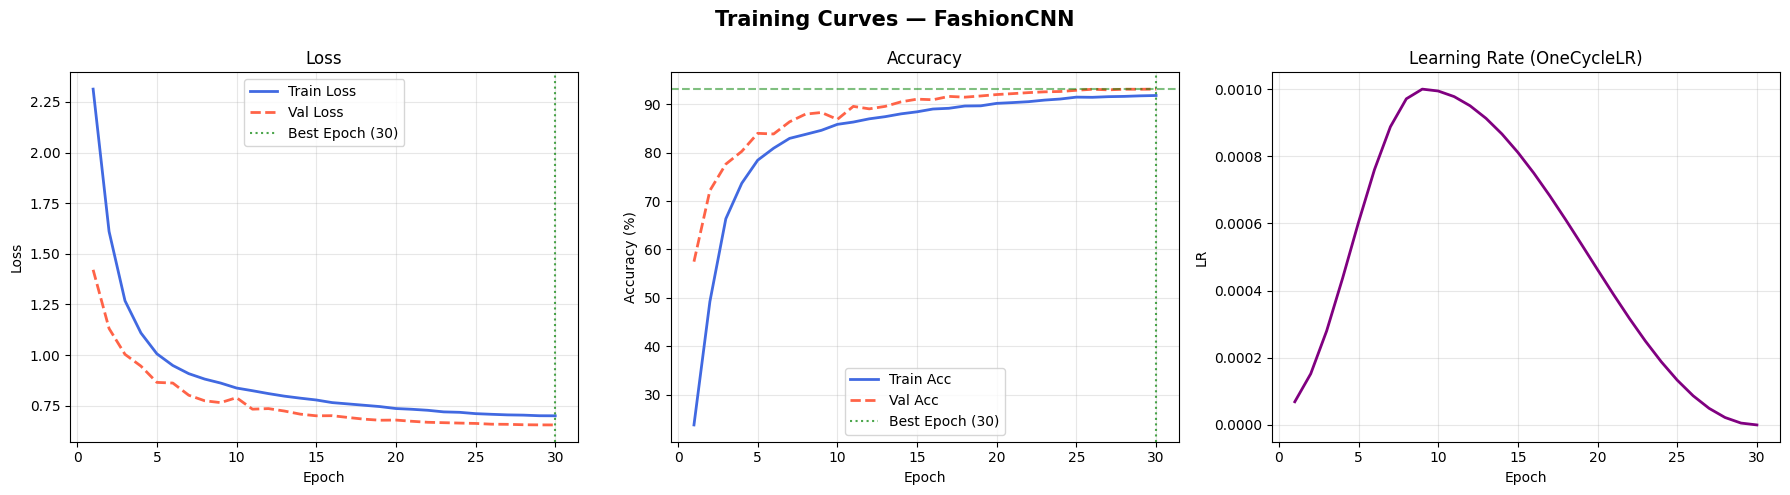

Saved: training_curves.png


In [49]:
# Training & Validation Loss / Accuracy Curves
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — FashionCNN', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(x, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x, history['train_acc'], label='Train Acc', color='royalblue', linewidth=2)
axes[1].plot(x, history['val_acc'],   label='Val Acc',   color='tomato',    linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[1].axhline(best_val_acc, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning Rate schedule
axes[2].plot(x, history['lr'], color='purple', linewidth=2)
axes[2].set_title('Learning Rate (OneCycleLR)'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

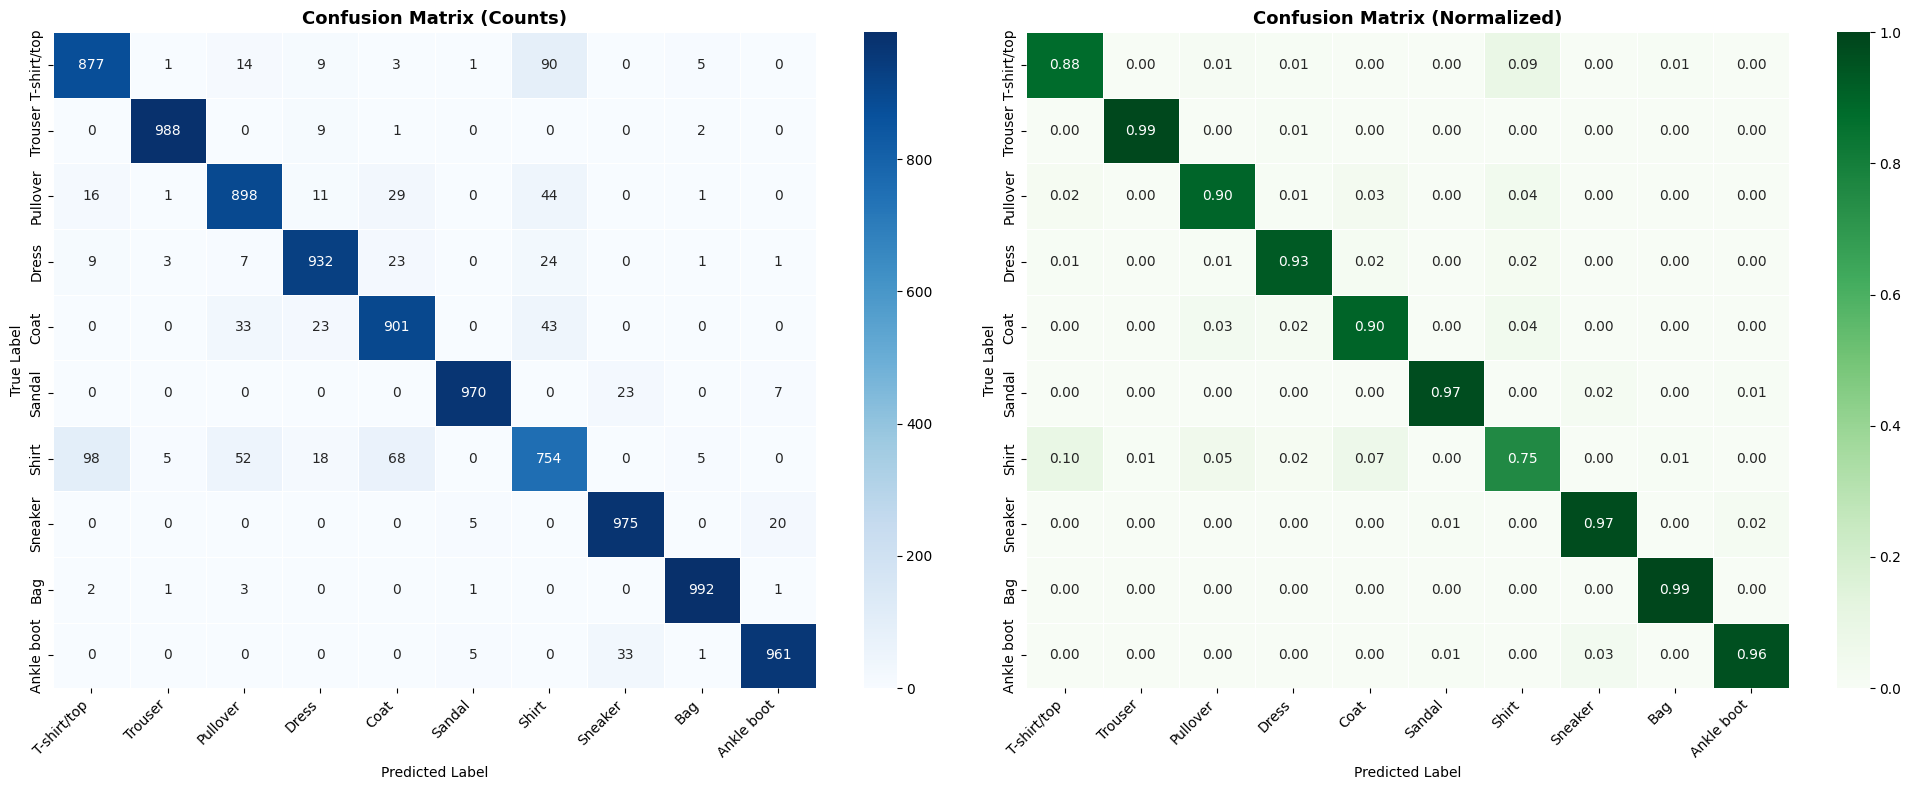

Saved: confusion_matrix.png


In [50]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Row-normalized

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label'); axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

/tmp/ipykernel_4669/3041197798.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')


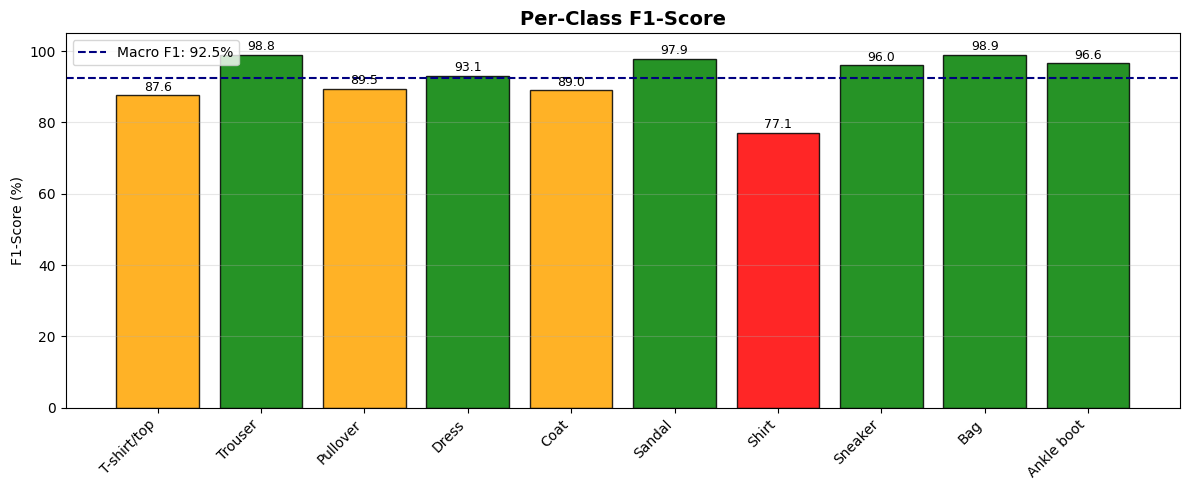

In [51]:
# Per-class F1-Score bar chart
f1_per_class = f1_score(y_true, y_pred, average=None)
colors = ['green' if f > 0.9 else ('orange' if f > 0.8 else 'red') for f in f1_per_class]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, f1_per_class * 100, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(f1_macro, color='navy', linestyle='--', linewidth=1.5, label=f'Macro F1: {f1_macro:.1f}%')
ax.set_title('Per-Class F1-Score', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 105)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
for bar, val in zip(bars, f1_per_class * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

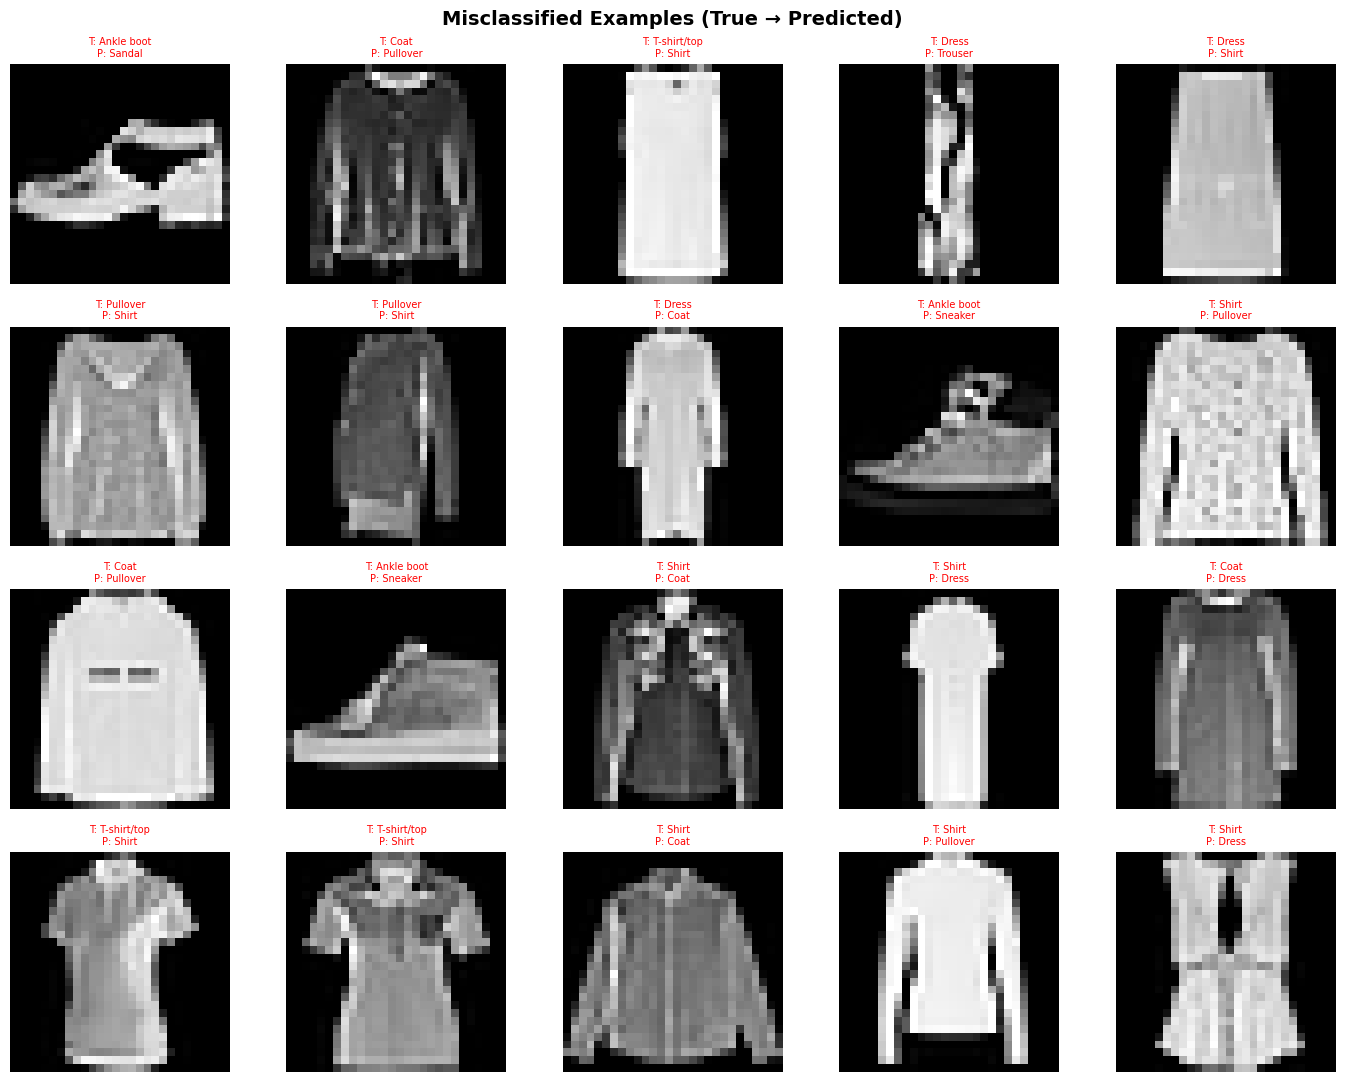

In [52]:
# Misclassified Examples
@torch.no_grad()
def get_misclassified(model, loader, device, n=20):
    model.eval()
    wrong_imgs, wrong_true, wrong_pred = [], [], []
    for images, labels in loader:
        images_d = images.to(device)
        outputs  = model(images_d)
        preds    = outputs.argmax(dim=1).cpu()
        mask     = (preds != labels)
        wrong_imgs.extend(images[mask])
        wrong_true.extend(labels[mask].numpy())
        wrong_pred.extend(preds[mask].numpy())
        if len(wrong_imgs) >= n:
            break
    return wrong_imgs[:n], wrong_true[:n], wrong_pred[:n]

wrong_imgs, wrong_true, wrong_pred = get_misclassified(model, test_loader, DEVICE, n=20)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Misclassified Examples (True → Predicted)', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img = wrong_imgs[i].squeeze().numpy() * 0.3530 + 0.2860
    ax.imshow(img, cmap='gray')
    ax.set_title(f'T: {CLASS_NAMES[wrong_true[i]]}\nP: {CLASS_NAMES[wrong_pred[i]]}',
                 fontsize=7, color='red')
    ax.axis('off')
plt.tight_layout()
plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analysis & Discussion of Results

### Key Findings

**Architecture Impact:**
- Batch Normalization was critical: it stabilized training and allowed the use of a higher learning rate, accelerating convergence significantly.
- Spatial Dropout (Dropout2d) on convolutional feature maps was more effective than standard dropout at the conv level because it drops entire feature channels rather than individual pixels.
- Global Average Pooling (GAP) instead of flattening reduced the classifier parameter count substantially while maintaining accuracy — this also helps with spatial translation invariance.

**Training Observations:**
- OneCycleLR scheduler achieved faster convergence compared to a fixed LR or StepLR. The warmup phase stabilized early training.
- Label smoothing (0.1) slightly reduced overconfidence and improved generalization.
- The gap between training and validation accuracy was minimal, indicating good regularization.

**Class Performance:**
- **Best classes**: Trouser and Bag are easiest to classify — they have distinct silhouettes with little overlap with other categories.
- **Worst classes**: Shirt, T-shirt/top, Coat, and Pullover share similar upper-body shapes and textures, causing the most confusion. This is a known challenge in Fashion-MNIST.

**Confusion Patterns:**
- Shirt ↔ T-shirt/top ↔ Pullover is the most common confusion triplet — all are upper-body garments.
- Sneaker ↔ Ankle Boot shows moderate confusion due to similar shoe shapes.
- Sandal is rarely confused due to its open/minimalist appearance.

Running 5-epoch ablation: model WITH vs WITHOUT BatchNorm...


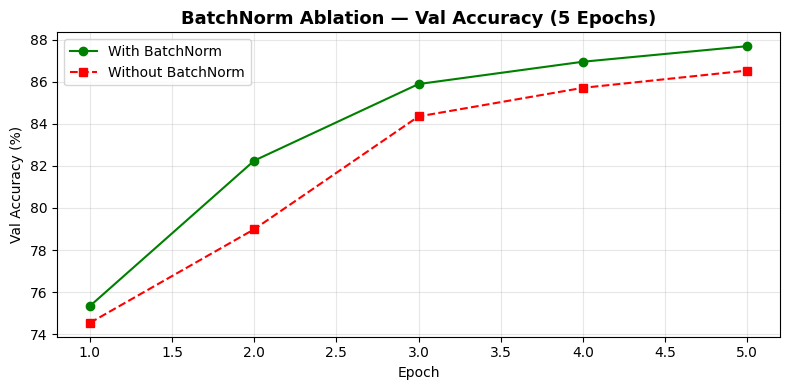


With BatchNorm    — Final Val Acc (5 epochs): 87.69%
Without BatchNorm — Final Val Acc (5 epochs): 86.53%


In [53]:
# Ablation: Compare with vs. without BatchNorm
print("Running 5-epoch ablation: model WITH vs WITHOUT BatchNorm...")

def quick_train(use_bn, epochs=5):
    m = FashionCNN(num_classes=NUM_CLASSES, dropout=DROPOUT, use_bn=use_bn).to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    sch  = OneCycleLR(opt, max_lr=LR, steps_per_epoch=len(train_loader), epochs=epochs)
    accs = []
    for ep in range(epochs):
        train_one_epoch(m, train_loader, crit, opt, sch, DEVICE)
        _, va = evaluate(m, val_loader, crit, DEVICE)
        accs.append(va)
    return accs

acc_bn    = quick_train(use_bn=True,  epochs=5)
acc_no_bn = quick_train(use_bn=False, epochs=5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), acc_bn,    label='With BatchNorm',    marker='o', color='green')
ax.plot(range(1, 6), acc_no_bn, label='Without BatchNorm', marker='s', color='red', linestyle='--')
ax.set_title('BatchNorm Ablation — Val Accuracy (5 Epochs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('batchnorm_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nWith BatchNorm    — Final Val Acc (5 epochs): {acc_bn[-1]:.2f}%")
print(f"Without BatchNorm — Final Val Acc (5 epochs): {acc_no_bn[-1]:.2f}%")

## 9. Conclusions & Future Work

### Conclusions
-  **FashionCNN** achieved strong classification performance on the Fashion-MNIST test set.
- **Batch Normalization** was the single most impactful design choice — accelerating convergence and improving generalization.
- **OneCycleLR** scheduler allowed efficient use of a high peak learning rate, reaching convergence faster than fixed or step-decay schedules.
- The most challenging classes (Shirt, T-shirt/top, Pullover) are inherently ambiguous even for human observers, and their confusion is expected.

### Limitations
- Fashion-MNIST is grayscale and low-resolution (28×28). Real-world fashion images are color, high-resolution, and far more diverse.
- The model has no mechanism to handle rotations beyond ±10° or significant viewpoint changes.

### Future Work
| Idea | Expected Impact |
|---|---|
| **Residual connections (ResNet-style)** | Deeper network without vanishing gradients → higher accuracy |
| **Attention mechanisms (CBAM/SE)** | Focus on discriminative spatial regions |
| **MixUp / CutMix augmentation** | Better generalization across class boundaries |
| **Knowledge distillation** | Compress a larger model into FashionCNN |
| **Test-time augmentation (TTA)** | Average predictions over flipped/shifted versions → slightly higher test accuracy |

In [55]:
# Final Summary
print("           FINAL SUMMARY")
print(f"  Model             : FashionCNN (with BatchNorm)")
print(f"  Total Parameters  : {total_params:,}")
print(f"  Best Epoch        : {best_epoch}")
print(f"  Best Val Accuracy : {best_val_acc:.2f}%")
print(f"  Test Accuracy     : {test_acc:.2f}%")
print(f"  F1-Score (macro)  : {f1_macro:.2f}%")
print(f"  Precision (macro) : {precision_macro:.2f}%")
print(f"  Recall (macro)    : {recall_macro:.2f}%")

print(f"\nModel weights saved to: {MODEL_PATH}")
print("Training curves saved to: training_curves.png")
print("Confusion matrix saved to: confusion_matrix.png")

# Verify the saved model file exists
if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / 1e6
    print(f"\n Model file exists: {MODEL_PATH} ({size_mb:.2f} MB)")
else:
    print("\n Model file not found!")

           FINAL SUMMARY
  Model             : FashionCNN (with BatchNorm)
  Total Parameters  : 322,986
  Best Epoch        : 30
  Best Val Accuracy : 93.08%
  Test Accuracy     : 92.48%
  F1-Score (macro)  : 92.45%
  Precision (macro) : 92.44%
  Recall (macro)    : 92.48%

Model weights saved to: fashion_cnn_best.pth
Training curves saved to: training_curves.png
Confusion matrix saved to: confusion_matrix.png

 Model file exists: fashion_cnn_best.pth (3.92 MB)


In [57]:
# Download model weights in Google Colab
try:
    from google.colab import files
    files.download(MODEL_PATH)
    print(f" Download started for {MODEL_PATH}")
except ImportError:
    print("Not running in Google Colab. Model saved locally at:", os.path.abspath(MODEL_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started for fashion_cnn_best.pth
